# Store-writer overhead

Reads `results_store_writer_overhead.csv` (from `run_store_writer_overhead.py`) and plots the overhead of the `StatisticStoreWriter` operator per aggregation.

For each parameter combination the build query is run twice — WITH the writer (`store_writer=on`) and WITHOUT it (`off`). The build runs identically in both, so `overhead = throughput(off) - throughput(on)` isolates the writer's per-window insertion cost. Mirrors the `StatisticBuild.ipynb` overhead-vs-Sum plot: x = memory budget, hue = aggregation, one panel per window size, one figure per (dataset, threads).

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Shared "paper" look, kept in sync with the sibling benchmarking notebooks (Statistic Stores.ipynb,
# StatisticGrid.ipynb): white background, colorblind palette, dotted y-grid, and only the left/bottom
# spines. "ticks" (not "whitegrid") is what makes the despine below leave a clean L-shaped frame.
# Axis text sits above the ~1:1 paper sizes: these panels are placed as narrow subfigures and scaled
# down further, so the labels have to start bigger to survive it.
PAPER_RC = {
    "axes.labelsize": 11, "axes.titlesize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.linewidth": 0.6, "lines.linewidth": 1.2, "lines.markersize": 3,
    "pdf.fonttype": 42, "ps.fonttype": 42,  # TrueType, not Type-3: ACM/IEEE preflight rejects Type-3
}
sns.set_theme(style="ticks", context="paper", palette="colorblind", rc=PAPER_RC)
PALETTE = "colorblind"


def style_axis(ax, grid_axis="y"):
    """Dotted grid on the value axis, short ticks, and top/right spines removed."""
    ax.grid(True, axis=grid_axis, linestyle=":", linewidth=0.5, alpha=0.6)
    ax.tick_params(length=2, width=0.6)
    sns.despine(ax=ax)


CSV = 'results_store_writer_overhead.csv'
df = pd.read_csv(CSV)
df = df[df['issue'] == 'ok'].copy()
df['tuplesPerSecond_listener'] = pd.to_numeric(df['tuplesPerSecond_listener'], errors='coerce')
df = df.dropna(subset=['tuplesPerSecond_listener'])
df = df[df['tuplesPerSecond_listener'] >= 0]
# These load as strings (the CSV has a stray repeated header), so sorts on them go lexicographic
# (1, 10, 5) and arithmetic like .max()*1.3 fails. Coerce once here so every downstream
# sorted()/x-axis orders numerically and the duration plots can scale their y-axis.
df['build_window_size_sec'] = df['build_window_size_sec'].astype(int)
df['memory_budget'] = df['memory_budget'].astype(int)
df['build_duration_s'] = pd.to_numeric(df['build_duration_s'], errors='coerce')

# Pair the on/off variants per (identity, run_idx) and compute the writer overhead.
keys = ['dataset', 'aggregation', 'memory_budget', 'build_window_size_sec', 'numberOfWorkerThreads', 'run_idx']
piv = df.pivot_table(index=keys, columns='store_writer', values='tuplesPerSecond_listener', aggfunc='mean').reset_index()
piv = piv.dropna(subset=['on', 'off'])
piv['overhead_mtp_s'] = (piv['off'] - piv['on']) / 1e6
piv['overhead_pct'] = np.where(piv['off'] > 0, (piv['off'] - piv['on']) / piv['off'] * 100, np.nan)
print(f'{len(piv)} paired on/off measurements across {piv["aggregation"].nunique()} aggregations')


def finalize_figure(fig, source_ax, suptitle, ncol, legend_title=None, legend=True):
    """Lay out a figure as title -> legend -> plot (top to bottom): the legend hugs the top of the panels
    (minimal legend-to-plot gap) and the suptitle sits clearly above the legend.

    Seaborn draws a legend per axis; we take the handles from one axis, remove all per-axis legends, and
    anchor a single horizontal figure-level legend by its bottom edge just above the axes. axes_top is kept
    low enough that the legend (which is two rows: its title + the entries) still clears the suptitle."""
    handles, labels = source_ax.get_legend_handles_labels()
    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    if not legend:
        # legend=False: the figure is one of several subfigures sharing ONE legend, exported
        # separately by save_legend(). No strip reserved here -> the panels use the full height.
        fig.tight_layout(rect=[0, 0, 1, 0.94 if suptitle else 1.0])
        if suptitle:
            fig.suptitle(suptitle, y=0.98)
        return
    axes_top = 0.80 if suptitle else 0.88  # no title -> the panels take the strip it would have used
    fig.tight_layout(rect=[0, 0, 1, axes_top])  # panels fill the figure up to axes_top
    # loc='lower center' anchors the legend's BOTTOM at bbox_to_anchor, so it sits right on top of the panels.
    fig.legend(handles, labels, title=legend_title, loc='lower center', bbox_to_anchor=(0.5, axes_top + 0.005),
               ncol=ncol, frameon=False, borderaxespad=0.0)
    if suptitle:
        fig.suptitle(suptitle, y=0.98)


def save_legend(source_ax, out, ncol, title=None, width=8.0):
    """Legend-only PDF for a row of subfigures rendered with finalize_figure(..., legend=False).
    Handles come from any axis that drew every series; width only has to be wide enough to keep the
    entries on one row, since bbox_inches='tight' crops the empty canvas away — LaTeX then sets the
    final size (\\includegraphics above the subfigure row)."""
    handles, labels = source_ax.get_legend_handles_labels()
    if not handles:
        return None
    legfig = plt.figure(figsize=(width, 0.35))
    ### The title goes to the LEFT of the entries, on the same row: matplotlib only ever stacks a
    ### legend title above them, so it is drawn as its own text instead. Both the legend and the text
    ### are anchored at an explicit figure fraction — with loc='center' the legend re-centres inside
    ### the crop region during a bbox_inches='tight' save while the text does not, and they collide.
    anchor = 0.4
    legfig.legend(handles, labels, loc='center left', bbox_to_anchor=(anchor, 0.5),
                  ncol=ncol, frameon=False)
    if title:
        legfig.text(anchor - 0.01, 0.5, f"{title}:", ha='right', va='center',
                    fontsize=plt.rcParams["legend.fontsize"])
    legfig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close(legfig)
    return out


piv.head()


def fmt_si(v):
    """Bar label: 15.9M / 1.6K / 4.7 — K/M/B suffixes with one decimal, never e-notation."""
    for div, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(v) >= div:
            return f"{v / div:.1f}{suffix}"
    return f"{v:.1f}" if abs(v) >= 1 else f"{v:.2g}"


450 paired on/off measurements across 6 aggregations


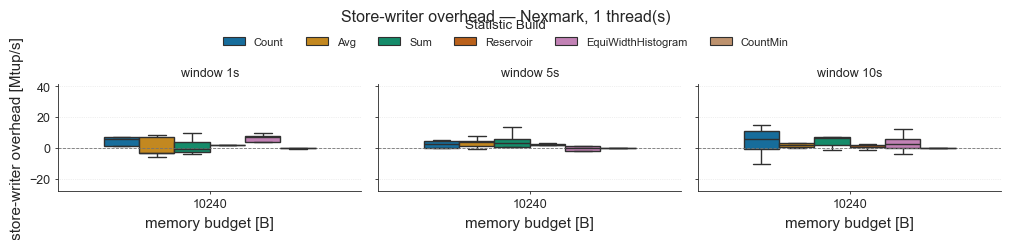

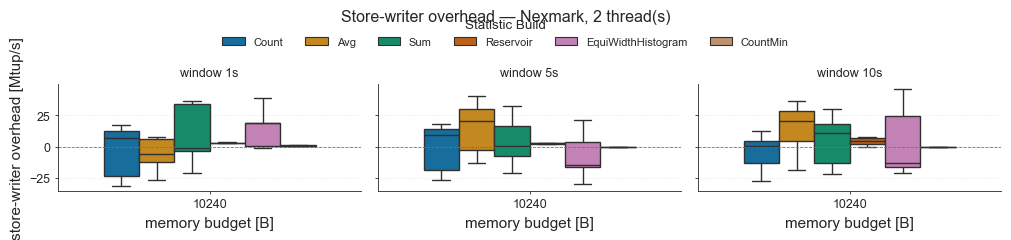

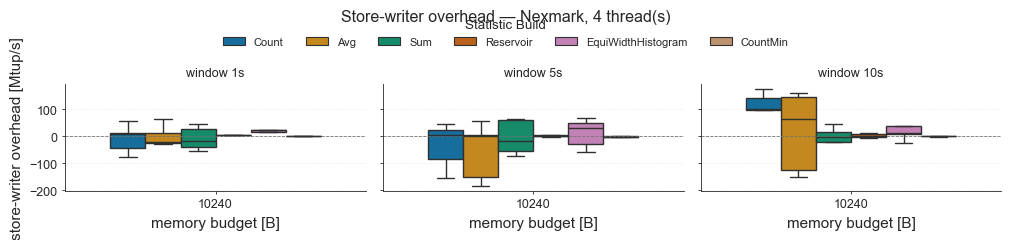

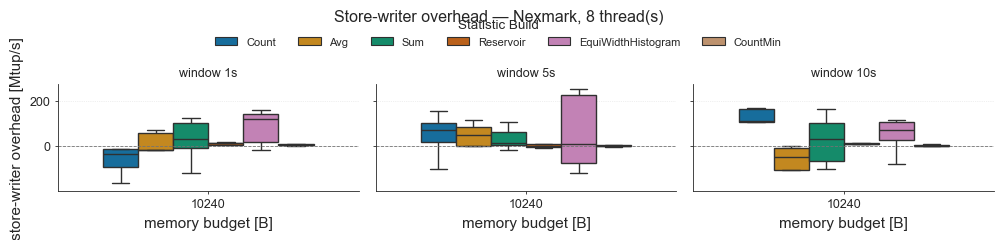

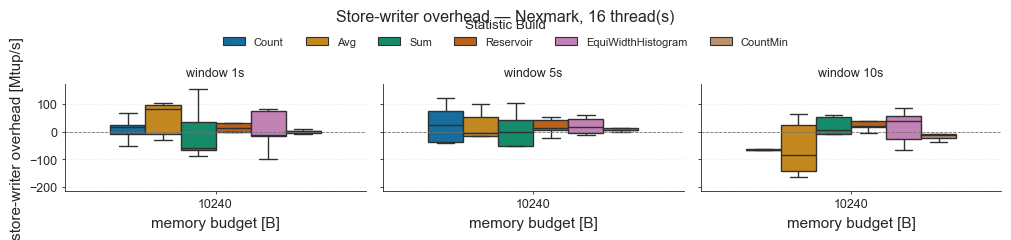

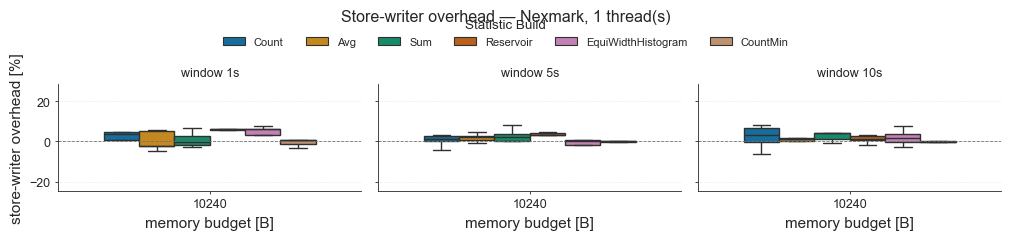

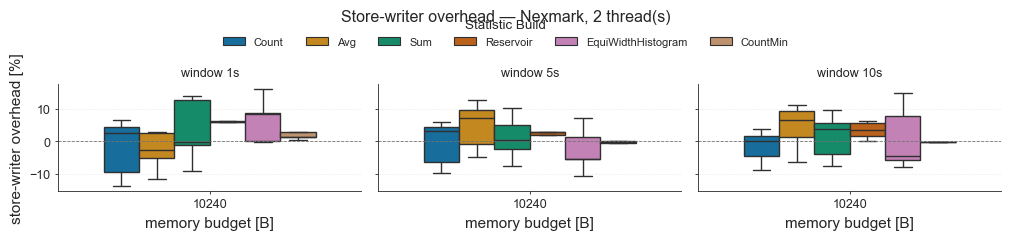

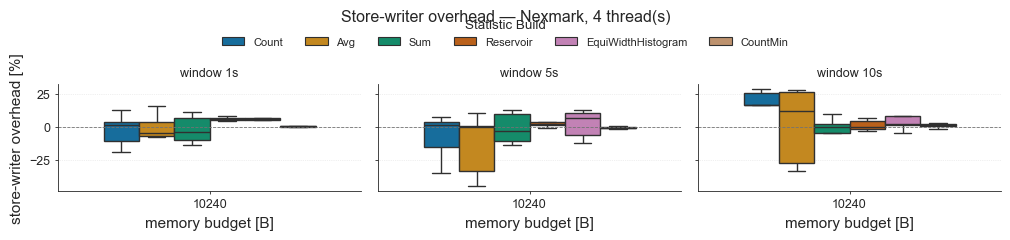

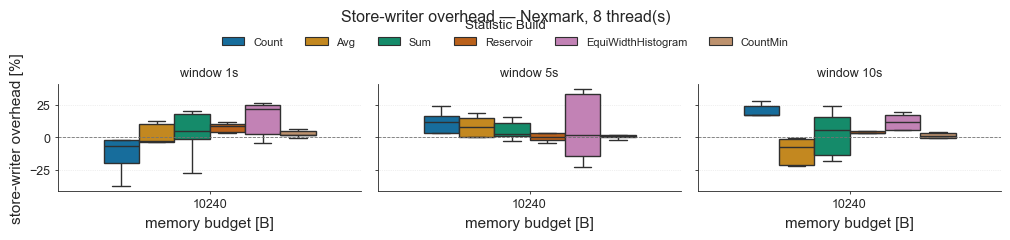

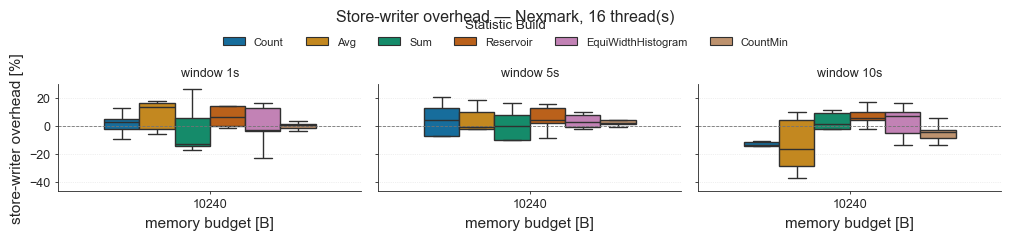

wrote:
  StoreWriterOverhead_Nexmark_threads1.pdf
  StoreWriterOverhead_Nexmark_threads2.pdf
  StoreWriterOverhead_Nexmark_threads4.pdf
  StoreWriterOverhead_Nexmark_threads8.pdf
  StoreWriterOverhead_Nexmark_threads16.pdf
  StoreWriterOverhead_Nexmark_threads1_percentage.pdf
  StoreWriterOverhead_Nexmark_threads2_percentage.pdf
  StoreWriterOverhead_Nexmark_threads4_percentage.pdf
  StoreWriterOverhead_Nexmark_threads8_percentage.pdf
  StoreWriterOverhead_Nexmark_threads16_percentage.pdf


In [2]:
AGG_ORDER = ['Count', 'Avg', 'Sum', 'Reservoir', 'EquiWidthHistogram', 'CountMin']

# Friendly x-tick labels (raw CSV values stay unchanged).
AGG_LABEL = {'Reservoir': 'Sample', 'EquiWidthHistogram': 'Histogram', 'CountMin': 'Sketch'}
X_LABEL = 'Statistic Build'   # what the aggregation axis is called in the paper
PANEL_W, PANEL_H = 3.4, 2.4   # per-panel inches, same scale as the sibling notebooks' figures


def agg_labels(order):
    return [AGG_LABEL.get(a, a) for a in order]

def plot_overhead(metric, ylabel, suffix):
    written = []
    for dataset in sorted(piv['dataset'].unique()):
        for threads in sorted(piv['numberOfWorkerThreads'].unique()):
            sub = piv[(piv['dataset'] == dataset) & (piv['numberOfWorkerThreads'] == threads)].dropna(subset=[metric])
            if sub.empty:
                continue
            fig_order = [a for a in AGG_ORDER if a in set(sub['aggregation'])]
            windows = sorted(sub['build_window_size_sec'].unique())
            fig, axes = plt.subplots(1, len(windows), figsize=(PANEL_W * len(windows), PANEL_H), squeeze=False, sharey=True)
            for c, (ax, w) in enumerate(zip(axes[0], windows)):
                d = sub[sub['build_window_size_sec'] == w]
                order = [a for a in AGG_ORDER if a in set(d['aggregation'])]
                sns.boxplot(data=d, x='memory_budget', y=metric, hue='aggregation', hue_order=order,
                            ax=ax, fliersize=0, width=0.7, palette=PALETTE)
                ax.axhline(0, color='0.45', lw=0.6, ls='--')
                ax.set_title(f'window {w}s')
                ax.set_xlabel('memory budget [B]')
                ax.set_ylabel(ylabel if c == 0 else '')
                style_axis(ax)
            finalize_figure(fig, axes[0][0], f'Store-writer overhead — {dataset}, {threads} thread(s)',
                            ncol=len(fig_order), legend_title=X_LABEL)
            out = f'StoreWriterOverhead_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()  # display inline (and, under nbconvert, embed the figure in the executed notebook)
    return written

written = plot_overhead('overhead_mtp_s', 'store-writer overhead [Mtup/s]', '')
written += plot_overhead('overhead_pct', 'store-writer overhead [%]', '_percentage')
print('wrote:')
for w in written:
    print(' ', w)

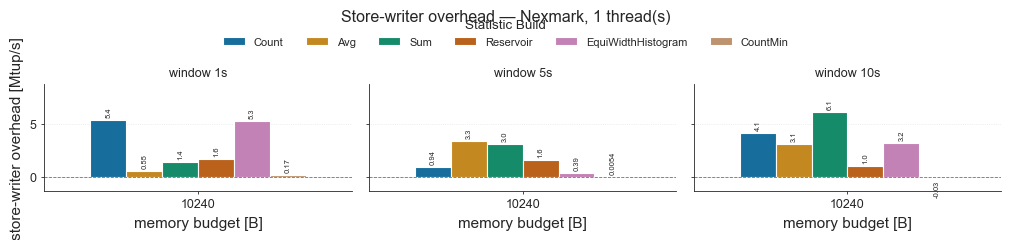

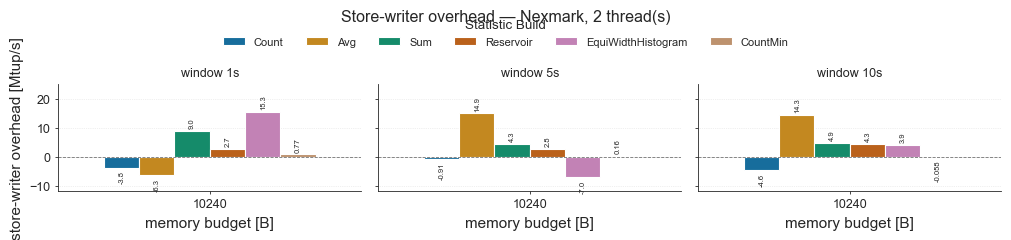

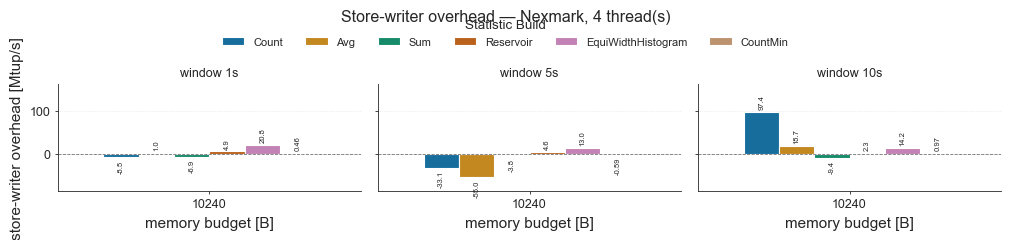

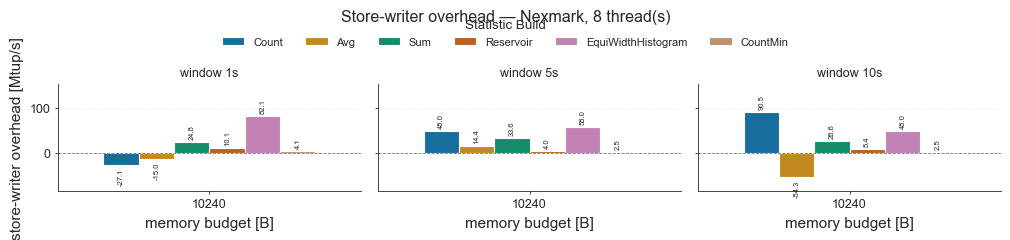

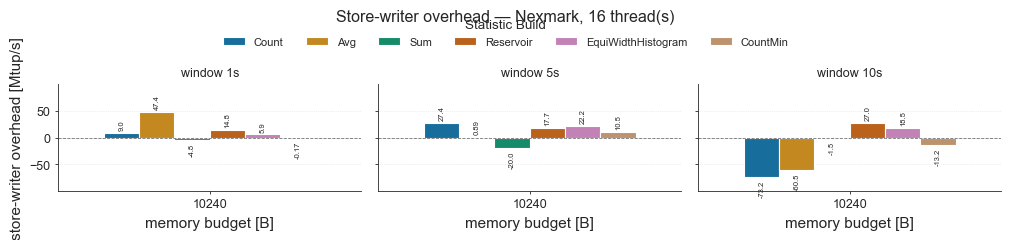

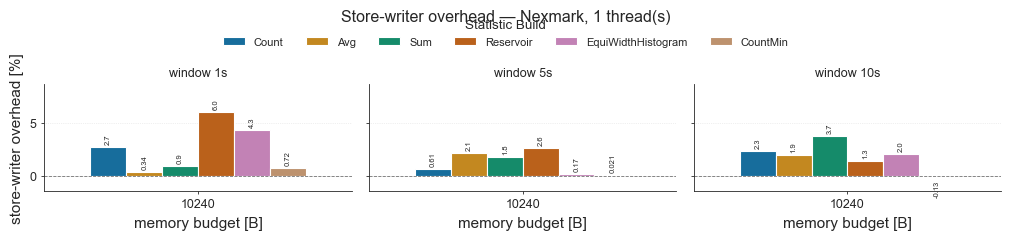

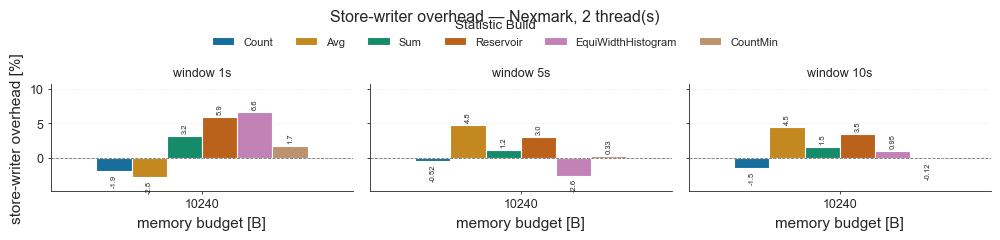

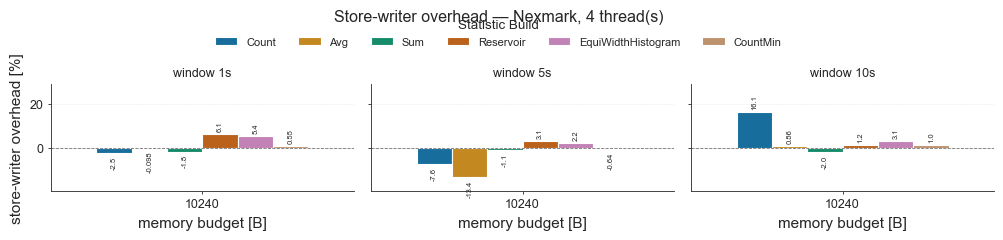

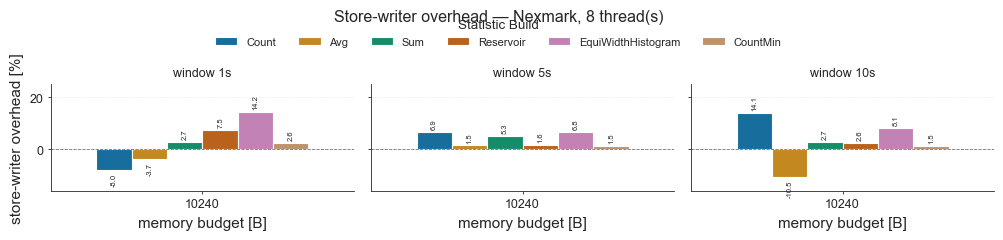

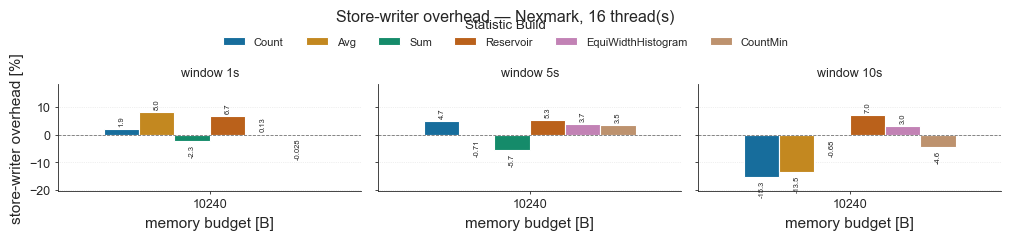

wrote:
  StoreWriterOverhead_Nexmark_threads1.pdf
  StoreWriterOverhead_Nexmark_threads2.pdf
  StoreWriterOverhead_Nexmark_threads4.pdf
  StoreWriterOverhead_Nexmark_threads8.pdf
  StoreWriterOverhead_Nexmark_threads16.pdf
  StoreWriterOverhead_Nexmark_threads1_percentage.pdf
  StoreWriterOverhead_Nexmark_threads2_percentage.pdf
  StoreWriterOverhead_Nexmark_threads4_percentage.pdf
  StoreWriterOverhead_Nexmark_threads8_percentage.pdf
  StoreWriterOverhead_Nexmark_threads16_percentage.pdf
  StoreWriterOverhead_Nexmark_threads1_bar.pdf
  StoreWriterOverhead_Nexmark_threads2_bar.pdf
  StoreWriterOverhead_Nexmark_threads4_bar.pdf
  StoreWriterOverhead_Nexmark_threads8_bar.pdf
  StoreWriterOverhead_Nexmark_threads16_bar.pdf
  StoreWriterOverhead_Nexmark_threads1_percentage_bar.pdf
  StoreWriterOverhead_Nexmark_threads2_percentage_bar.pdf
  StoreWriterOverhead_Nexmark_threads4_percentage_bar.pdf
  StoreWriterOverhead_Nexmark_threads8_percentage_bar.pdf
  StoreWriterOverhead_Nexmark_threads1

In [3]:
AGG_ORDER = ['Count', 'Avg', 'Sum', 'Reservoir', 'EquiWidthHistogram', 'CountMin']

def plot_overhead_bar(metric, ylabel, suffix):
    written = []
    for dataset in sorted(piv['dataset'].unique()):
        for threads in sorted(piv['numberOfWorkerThreads'].unique()):
            sub = piv[(piv['dataset'] == dataset) & (piv['numberOfWorkerThreads'] == threads)].dropna(subset=[metric])
            if sub.empty:
                continue
            fig_order = [a for a in AGG_ORDER if a in set(sub['aggregation'])]
            windows = sorted(sub['build_window_size_sec'].unique())
            fig, axes = plt.subplots(1, len(windows), figsize=(PANEL_W * len(windows), PANEL_H), squeeze=False, sharey=True)
            for c, (ax, w) in enumerate(zip(axes[0], windows)):
                d = sub[sub['build_window_size_sec'] == w]
                order = [a for a in AGG_ORDER if a in set(d['aggregation'])]
                sns.barplot(data=d, x='memory_budget', y=metric, hue='aggregation',
                            hue_order=order, errorbar=None, ax=ax, palette=PALETTE, width=0.7)
                ax.axhline(0, color='0.45', lw=0.6, ls='--')
                ax.set_title(f'window {w}s')
                ax.set_xlabel('memory budget [B]')
                ax.set_ylabel(ylabel if c == 0 else '')
                style_axis(ax)
                # Value on top of every bar; rotated so the many hue bars per budget don't collide.
                for container in ax.containers:
                    ax.bar_label(container, labels=[fmt_si(b.get_height()) for b in container], fontsize=5.5, padding=2, rotation=90)
            # Headroom for the rotated labels (shared y-axis, values can be negative).
            lo, hi = axes[0][0].get_ylim()
            axes[0][0].set_ylim(lo - (hi - lo) * 0.15, hi + (hi - lo) * 0.35)
            finalize_figure(fig, axes[0][0], f'Store-writer overhead — {dataset}, {threads} thread(s)',
                            ncol=len(fig_order), legend_title=X_LABEL)
            out = f'StoreWriterOverhead_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()  # display inline (and, under nbconvert, embed the figure in the executed notebook)
    return written

written += plot_overhead_bar('overhead_mtp_s', 'store-writer overhead [Mtup/s]', '_bar')
written += plot_overhead_bar('overhead_pct', 'store-writer overhead [%]', '_percentage_bar')
print('wrote:')
for w in written:
    print(' ', w)


/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


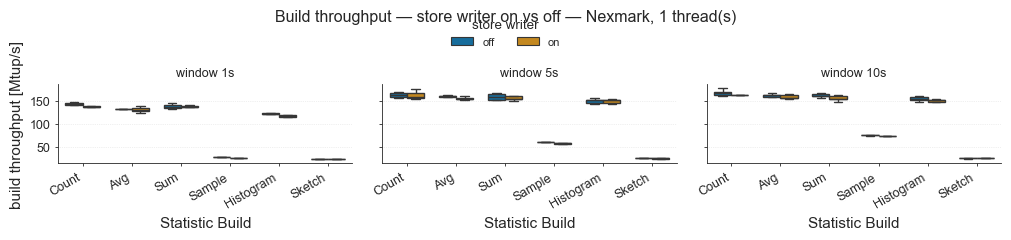

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


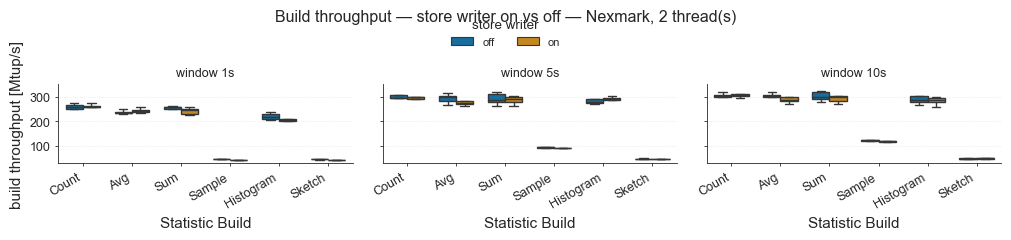

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


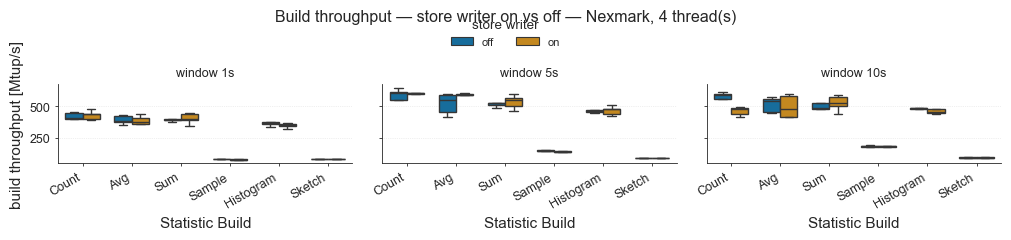

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


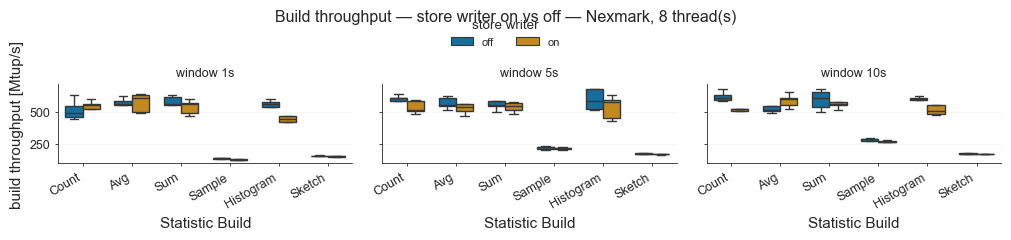

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1178190393.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


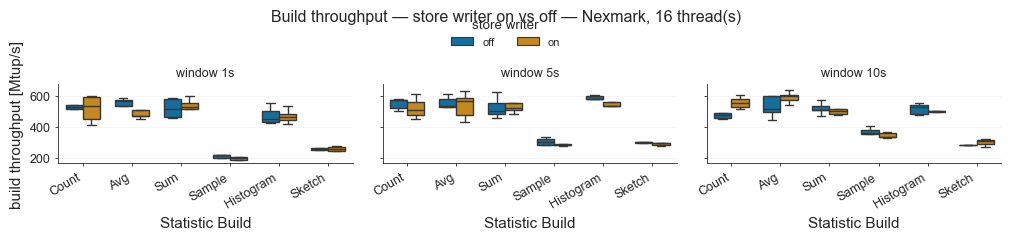

wrote:
  StoreWriterOnOff_Nexmark_threads1.pdf
  StoreWriterOnOff_Nexmark_threads2.pdf
  StoreWriterOnOff_Nexmark_threads4.pdf
  StoreWriterOnOff_Nexmark_threads8.pdf
  StoreWriterOnOff_Nexmark_threads16.pdf


In [4]:
# Raw build throughput WITH vs WITHOUT the store writer, hue = store_writer (on/off), per aggregation.
# The gap between the 'off' and 'on' box for each aggregation is the store-writer overhead.
df_ok = df.copy()
df_ok['throughput_mtp_s'] = df_ok['tuplesPerSecond_listener'] / 1e6

def plot_on_off(suffix=''):
    written = []
    for dataset in sorted(df_ok['dataset'].unique()):
        for threads in sorted(df_ok['numberOfWorkerThreads'].unique()):
            sub = df_ok[(df_ok['dataset'] == dataset) & (df_ok['numberOfWorkerThreads'] == threads)]
            if sub.empty:
                continue
            windows = sorted(sub['build_window_size_sec'].unique())
            fig, axes = plt.subplots(1, len(windows), figsize=(PANEL_W * len(windows), PANEL_H), squeeze=False, sharey=True)
            for c, (ax, w) in enumerate(zip(axes[0], windows)):
                d = sub[sub['build_window_size_sec'] == w]
                order = [a for a in AGG_ORDER if a in set(d['aggregation'])]
                sns.boxplot(data=d, x='aggregation', y='throughput_mtp_s', hue='store_writer',
                            order=order, hue_order=['off', 'on'], ax=ax, fliersize=0, width=0.7, palette=PALETTE)
                ax.set_title(f'window {w}s')
                ax.set_xlabel(X_LABEL)
                ax.set_ylabel('build throughput [Mtup/s]' if c == 0 else '')
                ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
                style_axis(ax)
            finalize_figure(fig, axes[0][0], f'Build throughput — store writer on vs off — {dataset}, {threads} thread(s)',
                            ncol=2, legend_title='store writer')
            out = f'StoreWriterOnOff_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()
    return written

onoff_written = plot_on_off()
print('wrote:')
for w in onoff_written:
    print(' ', w)

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


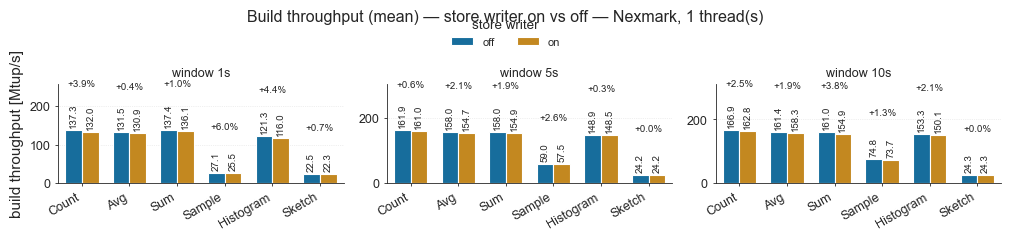

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


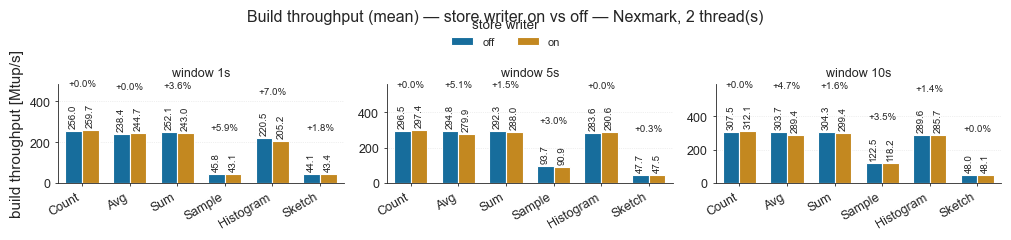

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


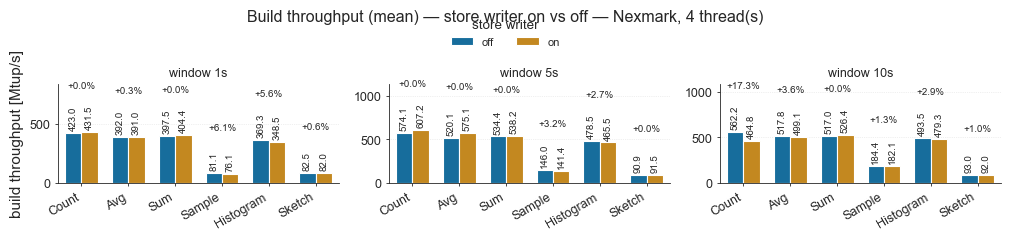

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


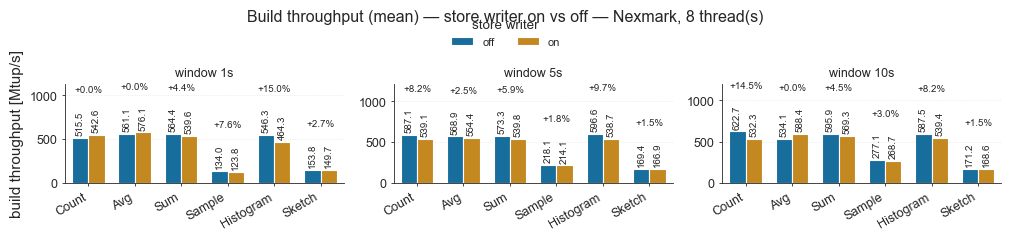

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


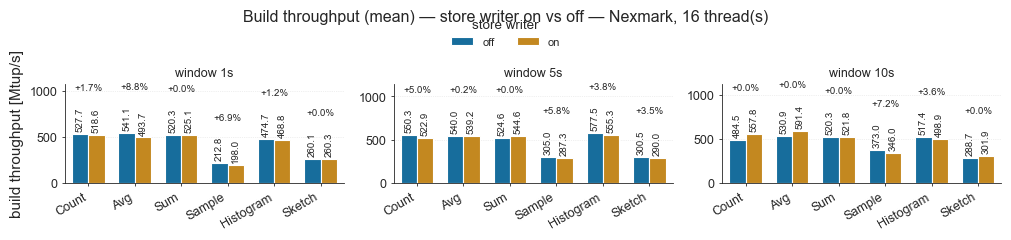

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


wrote:
  StoreWriterOnOffBars_Nexmark_threads1.pdf
  StoreWriterOnOffBars_Nexmark_threads2.pdf
  StoreWriterOnOffBars_Nexmark_threads4.pdf
  StoreWriterOnOffBars_Nexmark_threads8.pdf
  StoreWriterOnOffBars_Nexmark_threads16.pdf


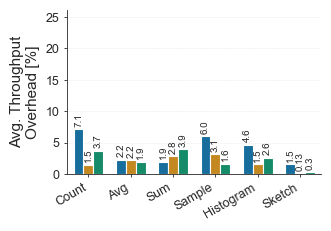

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


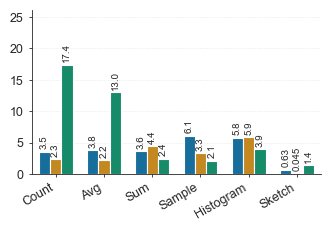

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


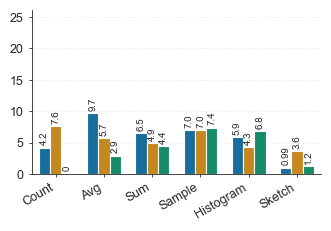

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


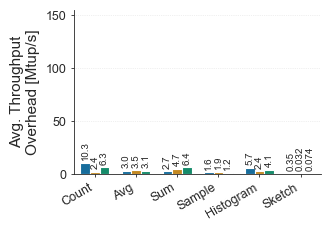

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


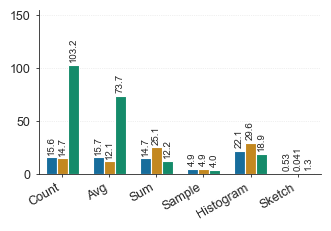

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/2167063970.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


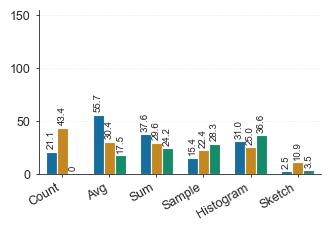

wrote:
  StoreWriterOnOffDiff_Nexmark_threads1_diff.pdf
  StoreWriterOnOffDiff_Nexmark_threads4_diff.pdf
  StoreWriterOnOffDiff_Nexmark_threads16_diff.pdf
  StoreWriterOnOffDiff_Nexmark_legend.pdf
  StoreWriterOnOffDiff_Nexmark_threads1_diff_absolute.pdf
  StoreWriterOnOffDiff_Nexmark_threads4_diff_absolute.pdf
  StoreWriterOnOffDiff_Nexmark_threads16_diff_absolute.pdf
  StoreWriterOnOffDiff_Nexmark_legend.pdf


In [5]:
# Same store-writer on/off comparison as bars (mean build throughput per group, no error bars).
# Each panel has its own linear y-axis from 0 up to its own max (with headroom for the labels), so
# every window's bars fill their panel. Every bar carries its own value, and each off/on pair carries
# one label centred over the pair: the signed change of 'on' vs the 'off' baseline, i.e. the
# store-writer's apparent cost.
# NOTE: these deltas are within run-to-run noise (~5-13% CV, 5 runs per group) — treat them as
# indistinguishable from zero, not as measured costs. Drop errorbar=None to see the spread.
def plot_on_off_bars(suffix=''):
    written = []
    for dataset in sorted(df_ok['dataset'].unique()):
        for threads in sorted(df_ok['numberOfWorkerThreads'].unique()):
            sub = df_ok[(df_ok['dataset'] == dataset) & (df_ok['numberOfWorkerThreads'] == threads)]
            if sub.empty:
                continue
            windows = sorted(sub['build_window_size_sec'].unique())
            fig, axes = plt.subplots(1, len(windows), figsize=(PANEL_W * len(windows), PANEL_H), squeeze=False, sharey=False)
            for c, (ax, w) in enumerate(zip(axes[0], windows)):
                d = sub[sub['build_window_size_sec'] == w]
                order = [a for a in AGG_ORDER if a in set(d['aggregation'])]
                sns.barplot(data=d, x='aggregation', y='throughput_mtp_s', hue='store_writer',
                            order=order, hue_order=['off', 'on'], errorbar=None, ax=ax, palette=PALETTE, width=0.7)
                # Headroom for the (now vertical) per-bar values and the per-pair % label above them.
                ax.set_ylim(0, d['throughput_mtp_s'].max() * 1.75)
                ax.set_title(f'window {w}s')
                ax.set_xlabel("")
                ax.set_ylabel('build throughput [Mtup/s]' if c == 0 else '')
                ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
                style_axis(ax)
                # Value above every bar, rotated 90 deg: upright it does not fit between two bars of a
                # pair at this panel width, and inside the bar it disappeared on the short ones.
                for container in ax.containers:
                    ax.bar_label(container, labels=[fmt_si(b.get_height()) for b in container], fontsize=7, padding=2, rotation=90)
                # One label per aggregation, centred over the off/on pair. The categorical x-axis puts
                # group i at x=i with the two bars straddling it, so x=i is the centre of the pair.
                means = d.groupby(['aggregation', 'store_writer'])['throughput_mtp_s'].mean()
                for i, a in enumerate(order):
                    off, on = means.get((a, 'off')), means.get((a, 'on'))
                    if not (off and on):
                        continue
                    # negative = the on-run was faster, i.e. run-to-run noise; floor at 0.
                    ### Cleared past the vertical value labels, which stand ~20pt tall above the bar.
                    ax.annotate(f'{max(0.0, (off - on) / off * 100):+.1f}%', xy=(i, max(off, on)), xytext=(0, 30),
                                textcoords='offset points', ha='center', va='bottom', fontsize=7)
            finalize_figure(fig, axes[0][0], f'Build throughput (mean) — store writer on vs off — {dataset}, {threads} thread(s)',
                            ncol=2, legend_title='store writer')
            out = f'StoreWriterOnOffBars_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()
    return written

bars_written = plot_on_off_bars()
print('wrote:')
for w in bars_written:
    print(' ', w)


# Companion plot: the off-vs-on difference itself, one bar per statistic build with the build window
# size as the hue, one panel per thread count — the same numbers as the % labels above, drawn as the
# y-value. Emitted twice: relative (overhead_pct) and absolute (overhead_mtp_s). The relative view
# hides that 1% at 16 threads is many more tuples/s than 1% at 1 thread; the absolute view hides that
# the per-thread baselines differ by ~10x — hence both. Shared y-axis so the thread counts are
# directly comparable. Bars are the mean over the 5 paired runs, no error bars; keep in mind the
# spread they would show covers zero everywhere — the writer fires once per window close (not per
# tuple) and build_duration_s moves by ~0.1%, so these deltas are run-to-run noise, growing from ~3%
# CV at 1 thread to ~9% at 8/16.
DIFF_THREADS = [1, 4, 16]  # the endpoints plus one middle point; 2/8 add nothing but panels


def plot_on_off_diff(metric='overhead_pct', ylabel='Avg. Throughput\nOverhead [%]',
                     suffix='_diff', tick_step=5):
    """tick_step pins the y ticks to a fixed grid (5 for percent, so 10% always gets its own tick
    instead of being swallowed by matplotlib's 0/20/40 autoscale); None keeps the automatic ticks."""
    written = []
    for dataset in sorted(piv['dataset'].unique()):
        sub_ds = piv[(piv['dataset'] == dataset) & (piv['numberOfWorkerThreads'].isin(DIFF_THREADS))]
        if sub_ds.empty:
            continue
        # a negative delta means the on-run was faster than the off-run, i.e. run-to-run noise, not a
        # speed-up from the writer -- floor it at 0 so the plot only shows real overhead.
        sub_ds = sub_ds.assign(**{metric: sub_ds[metric].clip(lower=0)})
        order = [a for a in AGG_ORDER if a in set(sub_ds['aggregation'])]
        windows = sorted(sub_ds['build_window_size_sec'].unique())
        thread_counts = sorted(sub_ds['numberOfWorkerThreads'].unique())
        legend_ax = None  # first panel built for this dataset — source of the shared legend
        # one y-limit for every thread count of a dataset, so the figures are comparable side by side.
        # Taken from the plotted bar heights (group means), not the raw runs.
        ymax = sub_ds.groupby(['numberOfWorkerThreads', 'aggregation', 'build_window_size_sec'])[metric].mean().max()
        for threads in thread_counts:
            d = sub_ds[sub_ds['numberOfWorkerThreads'] == threads]
            fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H))
            sns.barplot(data=d, x='aggregation', y=metric, order=order,
                        hue='build_window_size_sec', hue_order=windows,
                        errorbar=None, ax=ax, palette=PALETTE, width=0.7)
            ### 1.35, not 1.05: the vertical value labels need room above the tallest bar.
            ax.set_ylim(0, ymax * 1.5)
            ### Same treatment as the on/off bars: value above every bar, rotated 90 deg.
            for container in ax.containers:
                ax.bar_label(container, labels=[fmt_si(b.get_height()) for b in container],
                             fontsize=7, padding=2, rotation=90)
            ax.set_xlabel("")
            # only the lowest thread count carries the y-label; the figures sit side by side in the paper
            ax.set_ylabel(ylabel if threads == thread_counts[0] else '')
            ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
            style_axis(ax)
            if tick_step:
                ax.yaxis.set_major_locator(plt.MultipleLocator(tick_step))
            # No per-figure legend: the thread-count figures sit side by side in the paper under a
            # single legend, written once per dataset below.
            finalize_figure(fig, ax, '', ncol=len(windows), legend_title='Window Size [s]', legend=False)
            legend_ax = legend_ax or ax
            out = f'StoreWriterOnOffDiff_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()
        # Same hue (window size) for the relative and the absolute variant, so both calls write the
        # same legend file — the second one is a harmless rewrite of identical content.
        if legend_ax is not None:
            leg_out = save_legend(legend_ax, f'StoreWriterOnOffDiff_{dataset}_legend.pdf',
                                  ncol=len(windows), title='Window Size [s]')
            if leg_out:
                written.append(leg_out)
    return written


diff_written = plot_on_off_diff()
diff_written += plot_on_off_diff('overhead_mtp_s', 'Avg. Throughput\nOverhead [Mtup/s]',
                                 '_diff_absolute', tick_step=None)
print('wrote:')
for w in diff_written:
    print(' ', w)


/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


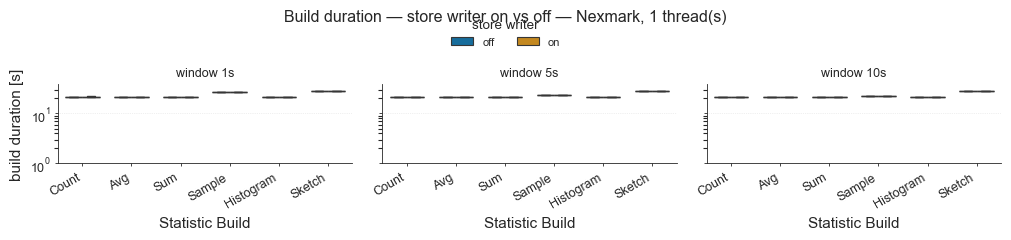

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


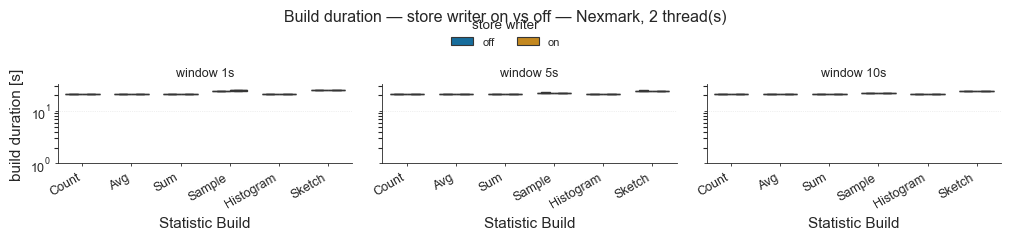

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


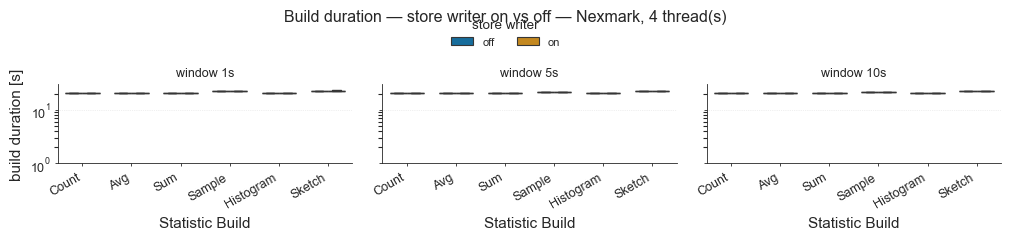

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


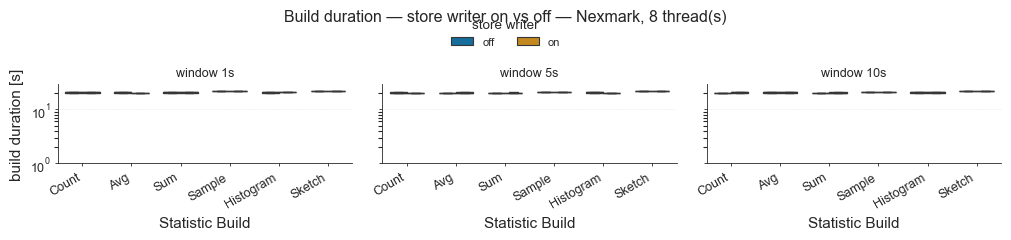

/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
/var/folders/4_/1pzvm57576q296fp5zpgkkr40000gn/T/ipykernel_76869/1236615516.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')


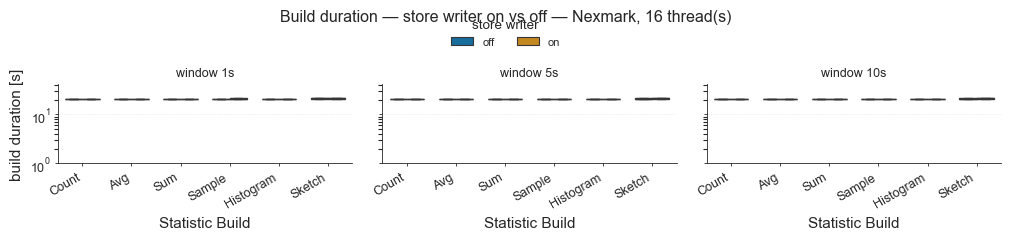

wrote:
  StoreWriterDuration_Nexmark_threads1.pdf
  StoreWriterDuration_Nexmark_threads2.pdf
  StoreWriterDuration_Nexmark_threads4.pdf
  StoreWriterDuration_Nexmark_threads8.pdf
  StoreWriterDuration_Nexmark_threads16.pdf


In [6]:
# Build wall-clock duration WITH vs WITHOUT the store writer, hue = store_writer (on/off), per aggregation.
# This is the cleaner signal for the writer cost: the StatisticStoreWriter runs once per window (not per
# tuple), so its cost shows up more reliably in total build time than in the source-bound throughput. A
# taller 'on' box than 'off' is the writer's overhead. Panels share a log y-axis (starting at 1 s), with the
# shared top taken from the max across all panels so no panel is clipped.
def plot_duration(suffix=''):
    written = []
    for dataset in sorted(df_ok['dataset'].unique()):
        for threads in sorted(df_ok['numberOfWorkerThreads'].unique()):
            sub = df_ok[(df_ok['dataset'] == dataset) & (df_ok['numberOfWorkerThreads'] == threads)]
            if sub.empty:
                continue
            windows = sorted(sub['build_window_size_sec'].unique())
            fig, axes = plt.subplots(1, len(windows), figsize=(PANEL_W * len(windows), PANEL_H), squeeze=False, sharey=True)
            for c, (ax, w) in enumerate(zip(axes[0], windows)):
                d = sub[sub['build_window_size_sec'] == w]
                order = [a for a in AGG_ORDER if a in set(d['aggregation'])]
                sns.boxplot(data=d, x='aggregation', y='build_duration_s', hue='store_writer',
                            order=order, hue_order=['off', 'on'], ax=ax, fliersize=0, width=0.7, palette=PALETTE)
                ax.set_yscale('log')
                ax.set_title(f'window {w}s')
                ax.set_xlabel(X_LABEL)
                ax.set_ylabel('build duration [s]' if c == 0 else '')
                ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
                style_axis(ax)
            # One shared y-range (sharey), 1 .. overall max with headroom, so no panel gets clipped.
            axes[0][0].set_ylim(1, sub['build_duration_s'].max() * 1.3)
            finalize_figure(fig, axes[0][0], f'Build duration — store writer on vs off — {dataset}, {threads} thread(s)',
                            ncol=2, legend_title='store writer')
            out = f'StoreWriterDuration_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()
    return written

duration_written = plot_duration()
print('wrote:')
for w in duration_written:
    print(' ', w)

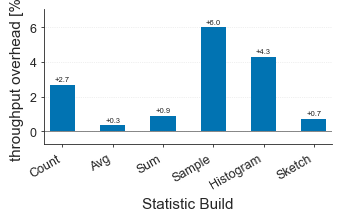

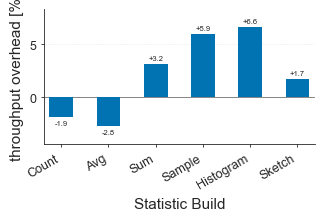

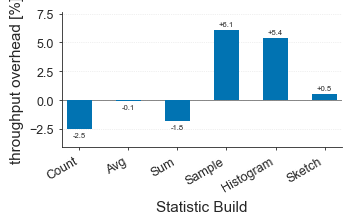

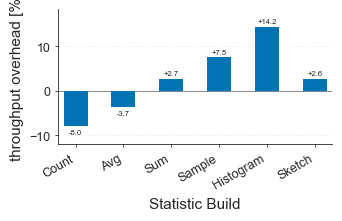

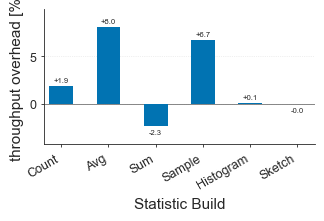

wrote:
  StoreWriterOverhead_Nexmark_threads1_w1s.pdf
  StoreWriterOverhead_Nexmark_threads2_w1s.pdf
  StoreWriterOverhead_Nexmark_threads4_w1s.pdf
  StoreWriterOverhead_Nexmark_threads8_w1s.pdf
  StoreWriterOverhead_Nexmark_threads16_w1s.pdf


In [7]:
# Store-writer throughput overhead for the 1s build window, one bar per aggregation (off-vs-on
# difference, same overhead_pct as cells 2/3 -- positive = writer lowers throughput). Styling comes
# from the shared PAPER_RC / style_axis set up in the first cell, so this matches the sibling
# benchmarking notebooks: single-column width, colorblind palette, embedded TrueType.
COL_W = 3.3                                     # single-column inches, as in the sibling notebooks
BAR_COLOR = sns.color_palette("colorblind")[0]  # blue, the highlighted-series colour used across plots/

def plot_overhead_1s(suffix='_w1s'):
    written = []
    for dataset in sorted(piv['dataset'].unique()):
        for threads in sorted(piv['numberOfWorkerThreads'].unique()):
            d = piv[(piv['dataset'] == dataset) & (piv['numberOfWorkerThreads'] == threads)
                    & (piv['build_window_size_sec'] == 1)]
            if d.empty:
                continue
            order = [a for a in AGG_ORDER if a in set(d['aggregation'])]
            means = d.groupby('aggregation')['overhead_pct'].mean().reindex(order)
            fig, ax = plt.subplots(figsize=(COL_W, 2.1))
            bars = ax.bar(range(len(order)), means.values, width=0.5, color=BAR_COLOR,
                          edgecolor='none', zorder=3)
            ax.axhline(0, color='0.45', lw=0.6, zorder=2)
            ax.set_xticks(range(len(order)))
            ax.set_xticklabels(agg_labels(order), rotation=30, ha='right')
            ax.set_xlabel(X_LABEL)
            ax.set_ylabel('throughput overhead [%]')
            ax.margins(x=0.02)
            style_axis(ax)
            # Value on top of every bar (below it for negative bars — bar_label handles both).
            ax.bar_label(bars, fmt='%+.1f', fontsize=5.5, padding=2)
            # Headroom so the labels aren't clipped at either end.
            lo, hi = ax.get_ylim()
            ax.set_ylim(lo - (hi - lo) * 0.12, hi + (hi - lo) * 0.12)
            fig.tight_layout(pad=0.3)
            out = f'StoreWriterOverhead_{dataset}_threads{threads}{suffix}.pdf'
            fig.savefig(out, dpi=300, bbox_inches='tight', pad_inches=0)
            written.append(out)
            plt.show()
    return written

overhead_1s_written = plot_overhead_1s()
print('wrote:')
for w in overhead_1s_written:
    print(' ', w)
